Using device: cuda
Generating and saving emojis...
Generated 1200 emojis in 6 categories.
Training...
Epoch 1 Loss: 0.07847892032249977
Epoch 2 Loss: 0.03650844023611985
Epoch 3 Loss: 0.012239279948469056
Epoch 4 Loss: 0.0020094588138530717
Epoch 5 Loss: 0.0008483172208989823
Epoch 6 Loss: 0.0002554216694797536
Epoch 7 Loss: 0.00011765890629153306
Epoch 8 Loss: 0.000841927537725209
Epoch 9 Loss: 0.0005461204349749574
Epoch 10 Loss: 9.051484841237605e-05
Epoch 11 Loss: 4.2273794717498515e-05
Epoch 12 Loss: 2.7783912628365215e-05
Epoch 13 Loss: 2.0097611779515557e-05
Epoch 14 Loss: 1.5206421697879896e-05
Epoch 15 Loss: 1.1894170591786909e-05
Epoch 16 Loss: 9.463668902753852e-06
Epoch 17 Loss: 7.678624175050094e-06
Epoch 18 Loss: 6.332984484240449e-06
Epoch 19 Loss: 5.3006884076909814e-06
Epoch 20 Loss: 4.532503345743814e-06
Training complete!


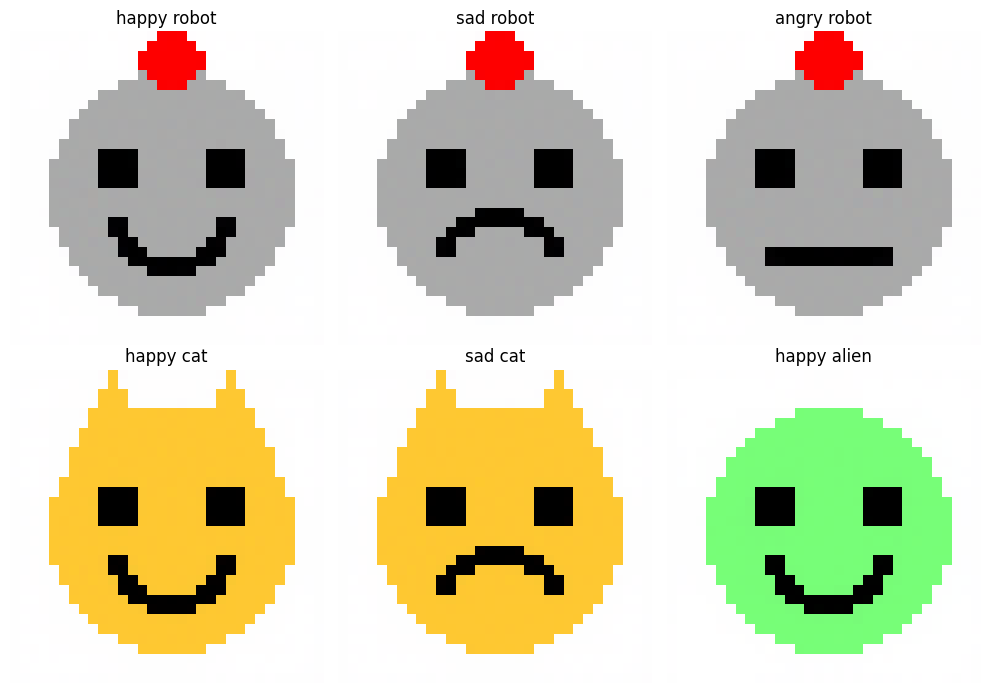

In [2]:
import os
import random
import numpy as np
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================

IMAGE_SIZE = 32
NUM_IMAGES = 1200
BATCH_SIZE = 32
EPOCHS = 30
NUM_COLORS = 32
LEARNING_RATE = 1e-3

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ============================================================
# CREATE SYNTHETIC EMOJI DATASET
# (NO DOWNLOADS -> NO ZIP ERRORS)
# ============================================================

DATASET_DIR = "/content/generated_emojis"

os.makedirs(DATASET_DIR, exist_ok=True)

categories = [
    "happy_robot",
    "sad_robot",
    "angry_robot",
    "happy_cat",
    "sad_cat",
    "happy_alien"
]

for category in categories:
    os.makedirs(os.path.join(DATASET_DIR, category), exist_ok=True)

# ============================================================
# EMOJI GENERATOR
# ============================================================

def create_emoji(emotion, species):

    img = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (255,255,255))

    draw = ImageDraw.Draw(img)

    # Face color
    if species == "robot":
        face_color = (170,170,170)

    elif species == "cat":
        face_color = (255,200,50)

    else:
        face_color = (120,255,120)

    # Face
    draw.ellipse(
        [4,4,28,28],
        fill=face_color
    )

    # Cat ears
    if species == "cat":

        draw.polygon(
            [(6,8),(10,0),(14,8)],
            fill=face_color
        )

        draw.polygon(
            [(18,8),(22,0),(26,8)],
            fill=face_color
        )

    # Robot antenna
    if species == "robot":

        draw.line(
            [(16,0),(16,5)],
            fill=(0,0,0),
            width=2
        )

        draw.ellipse(
            [13,0,19,5],
            fill=(255,0,0)
        )

    # Eyes
    eye_y = 12

    draw.rectangle(
        [9,eye_y,12,eye_y+3],
        fill=(0,0,0)
    )

    draw.rectangle(
        [20,eye_y,23,eye_y+3],
        fill=(0,0,0)
    )

    # Mouth
    if emotion == "happy":

        draw.arc(
            [10,14,22,24],
            start=0,
            end=180,
            fill=(0,0,0),
            width=2
        )

    elif emotion == "sad":

        draw.arc(
            [10,18,22,26],
            start=180,
            end=360,
            fill=(0,0,0),
            width=2
        )

    else:

        draw.line(
            [(10,22),(22,22)],
            fill=(0,0,0),
            width=2
        )

    return img

# ============================================================
# GENERATE AND SAVE EMOJIS
# ============================================================

print("Generating and saving emojis...")

for category_name in categories:
    emotion, species = category_name.split("_")
    for i in range(NUM_IMAGES // len(categories)):
        emoji_img = create_emoji(emotion, species)
        file_path = os.path.join(DATASET_DIR, category_name, f"emoji_{i:04d}.png")
        emoji_img.save(file_path)

print(f"Generated {NUM_IMAGES} emojis in {len(categories)} categories.")

# ============================================================
# SIMPLE CONDITIONAL EMOJI GENERATOR
# CLEAN OUTPUT VERSION
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================
# MODEL
# ============================================================

class EmojiGenerator(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(9, 64)

        self.fc = nn.Sequential(

            nn.Linear(64, 256),
            nn.ReLU(),

            nn.Linear(256, 8*8*128),
            nn.ReLU()

        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                128,
                64,
                4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                64,
                32,
                4,
                stride=2,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv2d(
                32,
                3,
                3,
                padding=1
            ),

            nn.Sigmoid()

        )

    def forward(self, labels):

        x = self.embedding(labels)

        x = self.fc(x)

        x = x.view(-1, 128, 8, 8)

        x = self.decoder(x)

        return x

# ============================================================
# CREATE LABELS
# ============================================================

def get_combined_label(emotion, species):

    emotion_map = {
        "happy":0,
        "sad":1,
        "angry":2
    }

    species_map = {
        "robot":0,
        "cat":1,
        "alien":2
    }

    return emotion_map[emotion] * 3 + species_map[species]

# ============================================================
# DATASET
# ============================================================

class CleanEmojiDataset(Dataset):

    def __init__(self, root_dir):

        self.samples = []

        folders = os.listdir(root_dir)

        for folder in folders:

            path = os.path.join(root_dir, folder)

            if not os.path.isdir(path):
                continue

            emotion, species = folder.split("_")

            label = get_combined_label(
                emotion,
                species
            )

            for file in os.listdir(path):

                self.samples.append((
                    os.path.join(path, file),
                    label
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]

        img = Image.open(path).convert("RGB")

        img = np.array(img) / 255.0

        img = torch.tensor(
            img,
            dtype=torch.float32
        ).permute(2,0,1)

        return img, torch.tensor(label)

# ============================================================
# LOAD DATASET
# ============================================================

dataset = CleanEmojiDataset(DATASET_DIR)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

# ============================================================
# MODEL
# ============================================================

model = EmojiGenerator().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.MSELoss()

# ============================================================
# TRAINING
# ============================================================

print("Training...")

for epoch in range(20):

    total_loss = 0

    for images, labels in loader:

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        outputs = model(labels);

        loss = criterion(outputs, images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss:",
        total_loss / len(loader)
    )

print("Training complete!")

# ============================================================
# GENERATE IMAGES
# ============================================================

model.eval()

samples = [

    ("happy","robot"),
    ("sad","robot"),
    ("angry","robot"),

    ("happy","cat"),
    ("sad","cat"),
    ("happy","alien")

]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(10,7)
)

with torch.no_grad():

    for ax, (emotion, species) in zip(
        axes.flatten(),
        samples
    ):

        label = get_combined_label(
            emotion,
            species
        )

        label = torch.tensor(
            [label]
        ).to(DEVICE)

        img = model(label)[0]

        img = img.permute(1,2,0).cpu().numpy()

        ax.imshow(img)

        ax.axis("off")

        ax.set_title(
            f"{emotion} {species}"
        )

plt.tight_layout()

plt.show()